In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

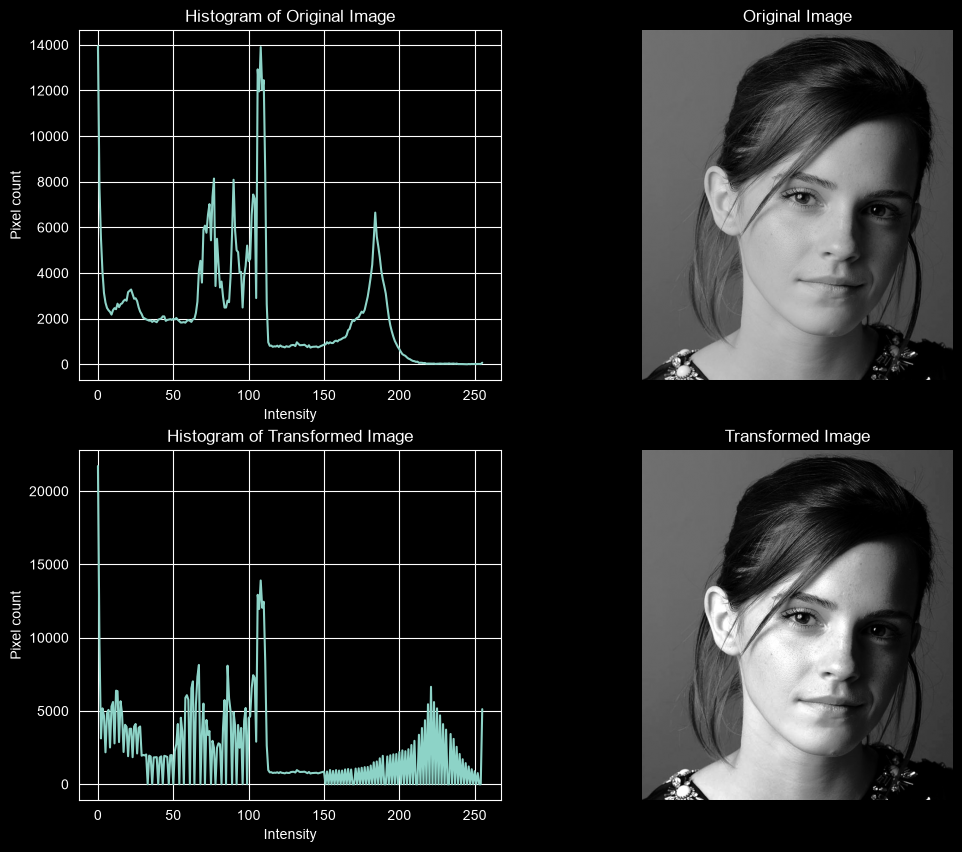

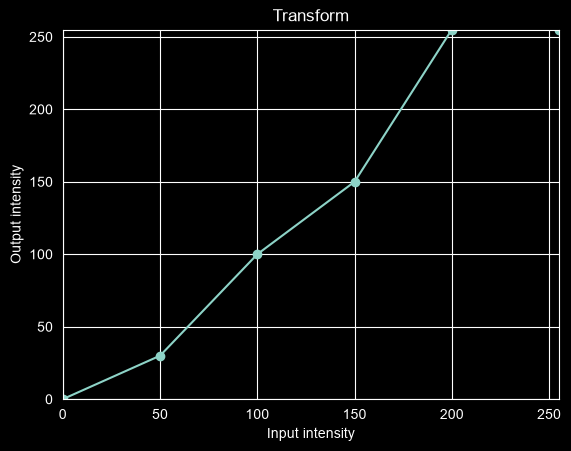

In [2]:
im = cv.imread("images/q1.jpeg", cv.IMREAD_GRAYSCALE)

hist = cv.calcHist([im], [0], None, [256], [0,256])

xp = [0, 50, 100, 150, 200, 255]
fp = [0, 30, 100, 150, 255, 255]

lut = np.interp(np.arange(256), xp, fp).astype(np.uint8)

transformed_image = cv.LUT(im, lut)
tr_hist = cv.calcHist([transformed_image], [0], None, [256], [0,256])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0][0].plot(hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Histogram of Original Image")

axes[0][1].imshow(im, cmap='gray', vmin=0, vmax=255)
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[1][0].plot(tr_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("Histogram of Transformed Image")

axes[1][1].imshow(transformed_image, cmap='gray', vmin=0, vmax=255)
axes[1][1].axis('off')
axes[1][1].set_title("Transformed Image")

plt.show()

plt.plot(xp, fp, 'o-')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Transform")

plt.show()

Text(0.5, 1.0, 'Gray Matter Image')

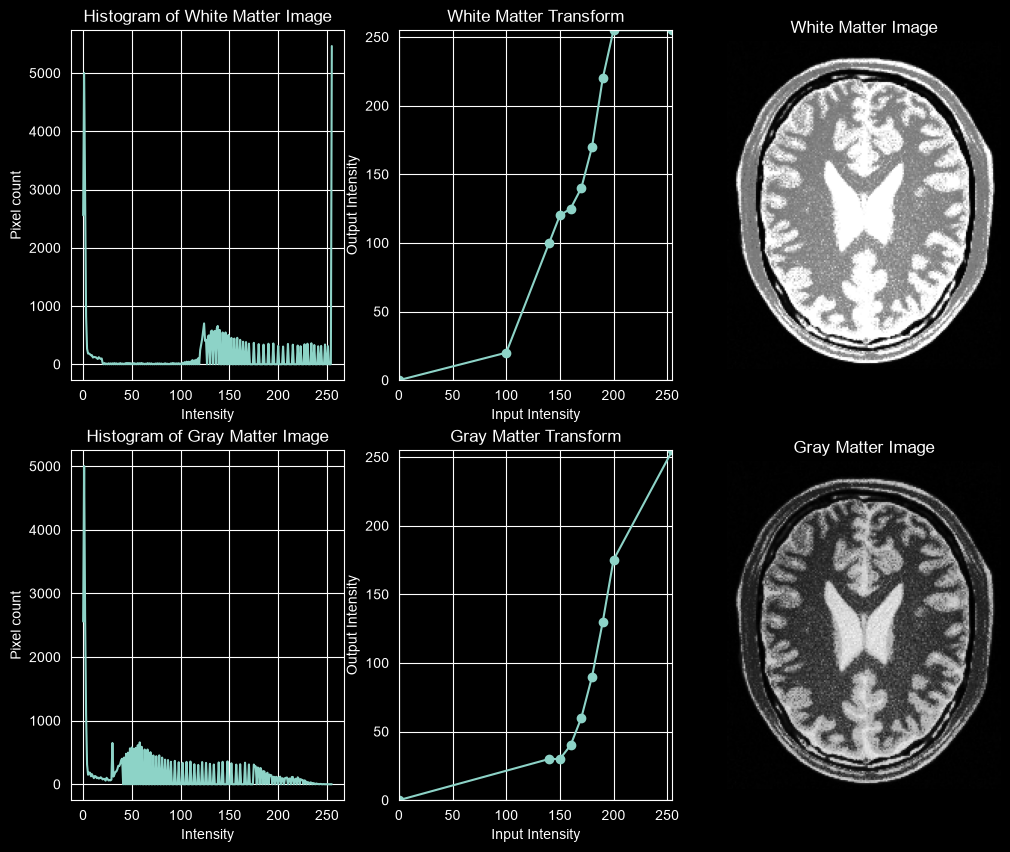

In [3]:
im = cv.imread("images/q2.jpeg")

hist = cv.calcHist([im], [0], None, [256], [0,256])

xp_wm = [0, 100, 140, 150, 160, 170, 180, 190, 200, 255]
fp_wm = [0,  20, 100, 120, 125, 140, 170, 220, 255, 255]

xp_gm = [0, 140, 150, 160, 170, 180, 190, 200, 255]
fp_gm = [0,  30,  30,  40,  60,  90, 130, 175, 255]

lut_wm = np.interp(np.arange(256), xp_wm, fp_wm).astype(np.uint8)
lut_gm = np.interp(np.arange(256), xp_gm, fp_gm).astype(np.uint8)

transformed_image_wm = cv.LUT(im, lut_wm)
wm_hist = cv.calcHist([transformed_image_wm], [0], None, [256], [0,256])

transformed_image_gm = cv.LUT(im, lut_gm)
gm_hist = cv.calcHist([transformed_image_gm], [0], None, [256], [0,256])

fig, axes = plt.subplots(2, 3, figsize=(12, 10))

axes[0][0].plot(wm_hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Histogram of White Matter Image")

axes[0][1].plot(xp_wm, fp_wm, 'o-')
axes[0][1].set_xlim(0,255)
axes[0][1].set_ylim(0,255)
axes[0][1].set_xlabel("Input Intensity")
axes[0][1].set_ylabel("Output Intensity")
axes[0][1].set_title("White Matter Transform")

axes[0][2].imshow(transformed_image_wm, cmap='gray')
axes[0][2].axis('off')
axes[0][2].set_title("White Matter Image")

axes[1][0].plot(gm_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("Histogram of Gray Matter Image")

axes[1][1].plot(xp_gm, fp_gm, 'o-')
axes[1][1].set_xlim(0,255)
axes[1][1].set_ylim(0,255)
axes[1][1].set_xlabel("Input Intensity")
axes[1][1].set_ylabel("Output Intensity")
axes[1][1].set_title("Gray Matter Transform")

axes[1][2].imshow(transformed_image_gm, cmap='gray')
axes[1][2].axis('off')
axes[1][2].set_title("Gray Matter Image")



Text(0.5, 1.0, 'Corrected Image')

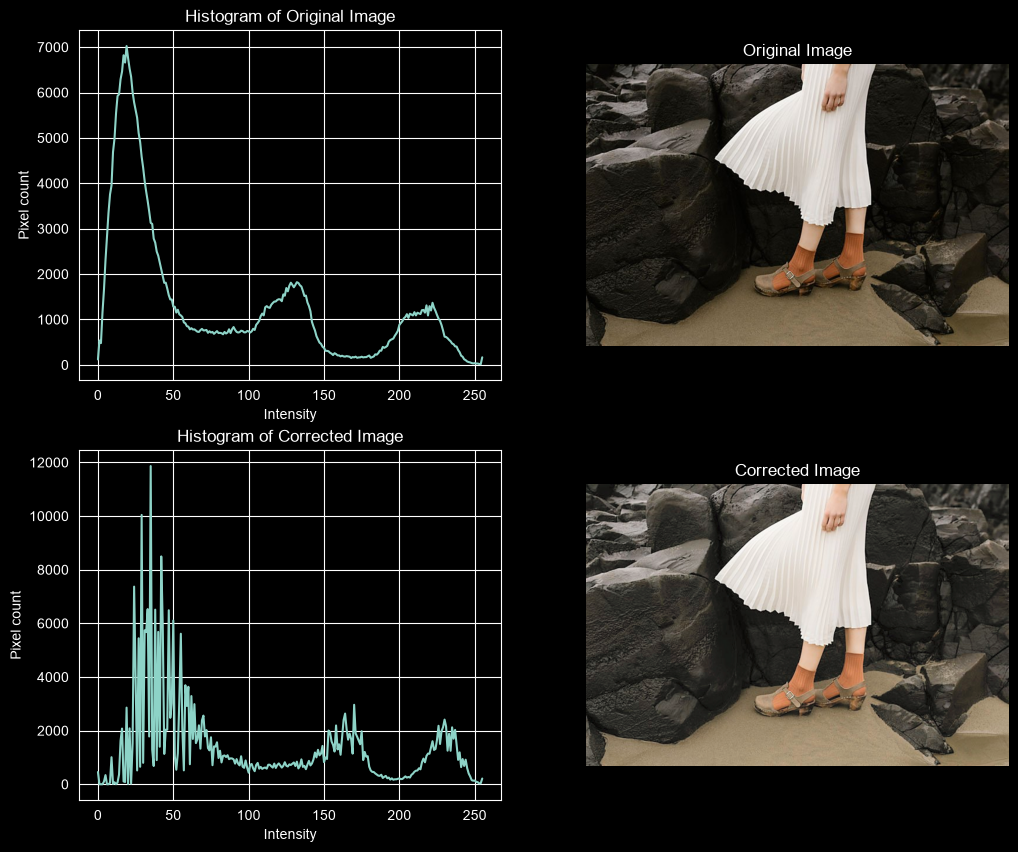

In [4]:
def gamma_correct(im, gamma):
    lut = np.array([((i/255.0)**gamma)*255 for i in np.arange(0, 256)]).astype("uint8")
    return cv.LUT(im, lut)

gamma = 0.65

im = cv.imread("images/q3.jpeg")
im_lab = cv.cvtColor(im, cv.COLOR_BGR2LAB)
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
hist = cv.calcHist([im_rgb], [0], None, [256], [0,256])

l_channel, a_channel, b_channel = cv.split(im_lab)

gamma_corrected_l = gamma_correct(l_channel, gamma)

reconstructed_im_lab = cv.merge([gamma_corrected_l, a_channel, b_channel])
reconstructed_im_rgb = cv.cvtColor(reconstructed_im_lab, cv.COLOR_LAB2RGB)
gamma_hist = cv.calcHist([reconstructed_im_rgb], [0], None, [256], [0,256])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0][0].plot(hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Histogram of Original Image")

axes[0][1].imshow(im_rgb)
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[1][0].plot(gamma_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("Histogram of Corrected Image")

axes[1][1].imshow(reconstructed_im_rgb)
axes[1][1].axis('off')
axes[1][1].set_title("Corrected Image")

Text(0.5, 1.0, 'Vibrance Transformed Image')

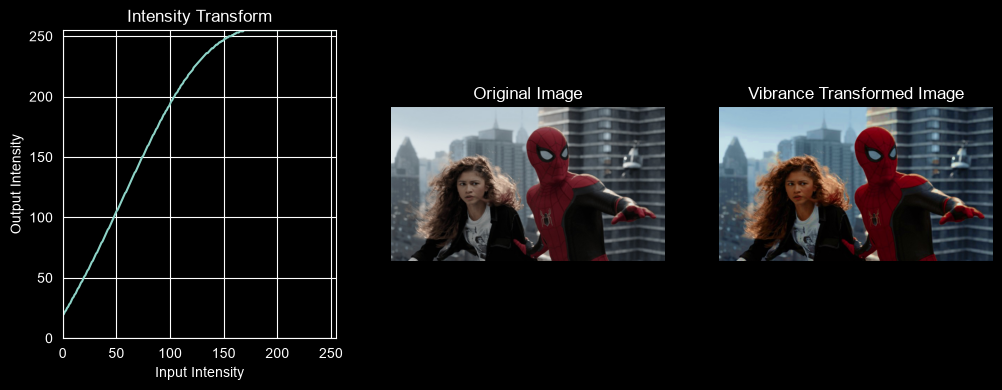

In [5]:
def vibrance_transform(i, a, sigma):
    f_inter = i + a*128*np.exp(-(i-128)**2/(2*sigma**2))
    f = min(f_inter, 255)
    return f

im = cv.imread("images/q4.jpeg")
im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
hue, saturation, value = cv.split(im_hsv)

a = 0.8
sigma = 70

lut = np.array([vibrance_transform(i, a, sigma) for i in np.arange(0, 256)]).astype("uint8")
im_sat_tform = cv.LUT(saturation, lut)

vibr_hsv = cv.merge([hue, im_sat_tform, value])

im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
vibr_rgb = cv.cvtColor(vibr_hsv, cv.COLOR_HSV2RGB) 

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(np.arange(256), lut)
axes[0].set_xlim(0,255)
axes[0].set_ylim(0,255)
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_title("Intensity Transform")

axes[1].imshow(im_rgb)
axes[1].axis('off')
axes[1].set_title("Original Image")

axes[2].imshow(vibr_rgb)
axes[2].axis('off')
axes[2].set_title("Vibrance Transformed Image")


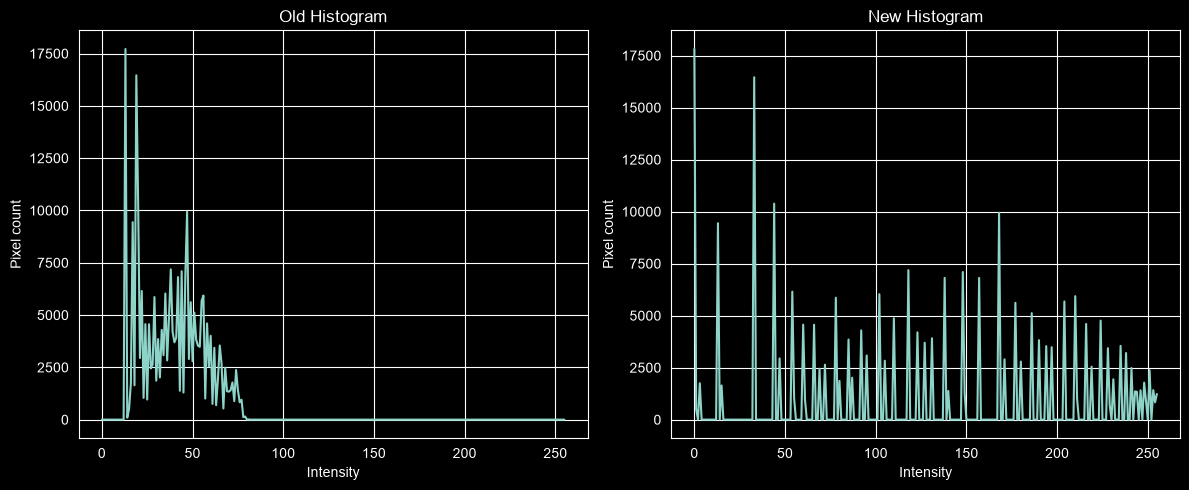

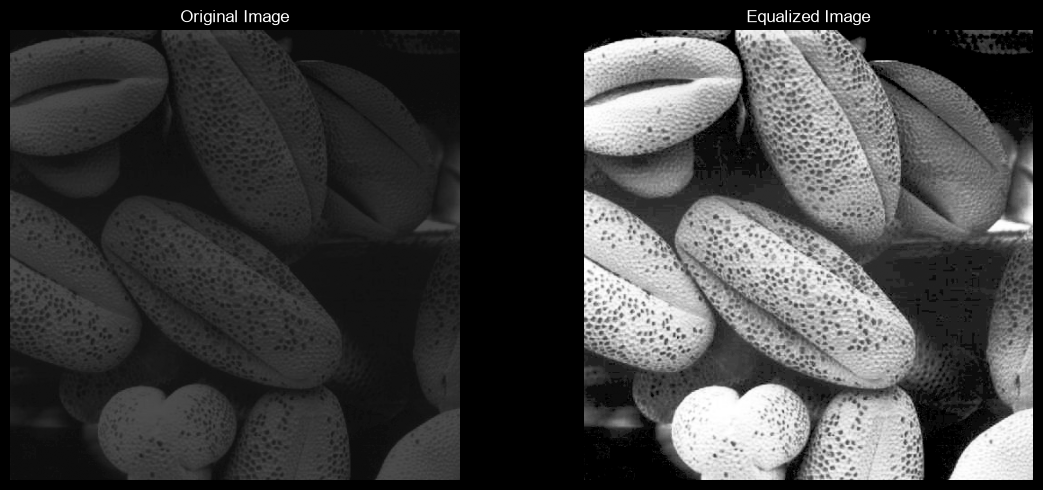

In [6]:
im = cv.imread("images/shells.tif", cv.IMREAD_GRAYSCALE)

old_hist = cv.calcHist([im], [0], None, [256], [0,256])

cdf = np.cumsum(old_hist)
cdf_min = cdf[cdf > 0].min()
lut = np.round((cdf-cdf_min) / (im.size-cdf_min) * 255).astype(np.uint8)
lut = np.clip(lut, 0, 255)

equalized_image = cv.LUT(im, lut)
new_hist = cv.calcHist([equalized_image], [0], None, [256], [0,256])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(old_hist)
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Pixel count")
axes[0].set_title("Old Histogram")

axes[1].plot(new_hist)
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Pixel count")
axes[1].set_title("New Histogram")

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

axes2[0].imshow(im, cmap='gray', vmin=0, vmax=255)
axes2[0].axis('off')
axes2[0].set_title("Original Image")

axes2[1].imshow(equalized_image, cmap='gray', vmin=0, vmax=255)
axes2[1].axis('off')
axes2[1].set_title("Equalized Image")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Value')

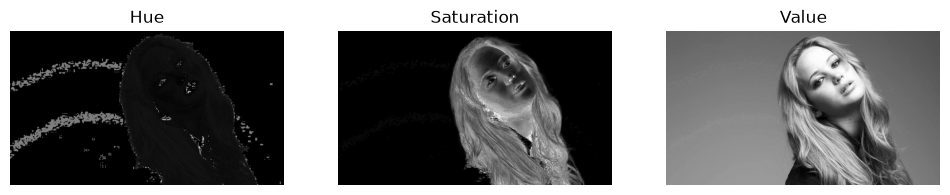

In [13]:
im = cv.imread("images/q6.jpeg")
im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
hue, saturation, value = cv.split(im_hsv)

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(hue, cmap='gray', vmin=0, vmax=255)
axes[0].axis('off')
axes[0].set_title("Hue")

axes[1].imshow(saturation, cmap='gray', vmin=0, vmax=255)
axes[1].axis('off')
axes[1].set_title("Saturation")

axes[2].imshow(value, cmap='gray', vmin=0, vmax=255)
axes[2].axis('off')
axes[2].set_title("Value")

In [ ]:
sat_hist = cv.calcHist([saturation], [0], None, [256], [0,256])

plt.figure(figsize=(10,4))
plt.plot(sat_hist)
plt.xlim(0, 60)
plt.xticks(np.arange(0, 61, 5))
plt.xlabel("Saturation")
plt.ylabel("Pixel count")
plt.title("Saturation Histogram (zoomed)")
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
thresh_val = 13 # Threshold value was taken as 13.

_, mask = cv.threshold(saturation, thresh_val, 255, cv.THRESH_BINARY) #Calculating mask

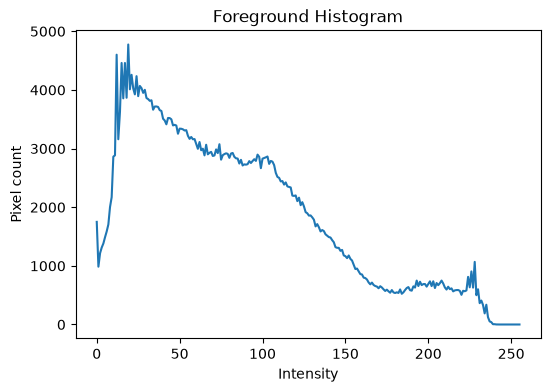

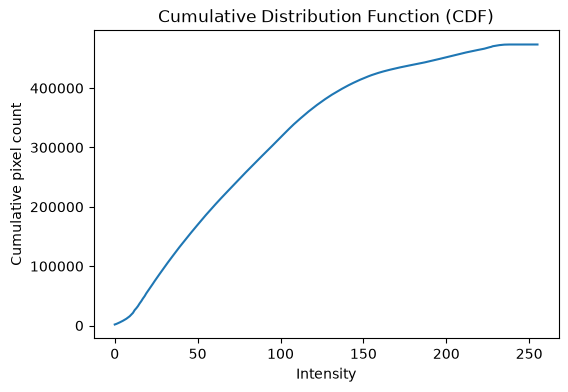

In [37]:
foreground = cv.bitwise_and(im, im, mask=mask)  #extract foreground

fore_hist = cv.calcHist([im], [0], mask, [256], [0,256]).flatten()
plt.figure(figsize=(6,4))
plt.plot(fore_hist)
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.title("Foreground Histogram")
plt.show()

cdf = np.cumsum(fore_hist)
plt.figure(figsize=(6,4))
plt.plot(cdf)
plt.xlabel("Intensity")
plt.ylabel("Cumulative pixel count")
plt.title("Cumulative Distribution Function (CDF)")
plt.show()


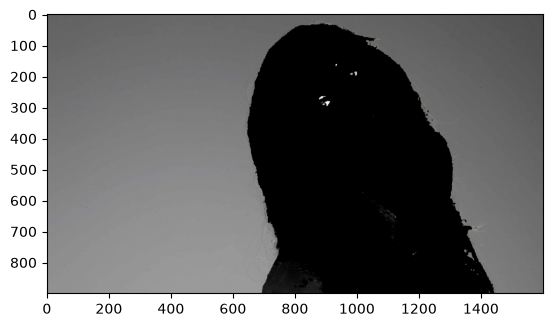

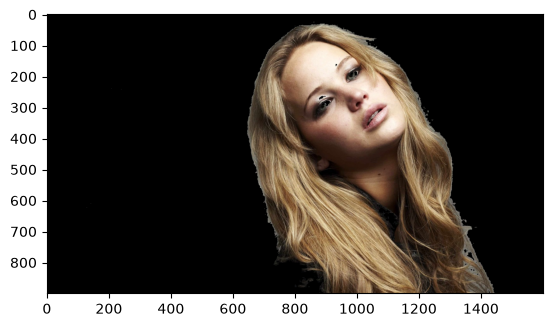

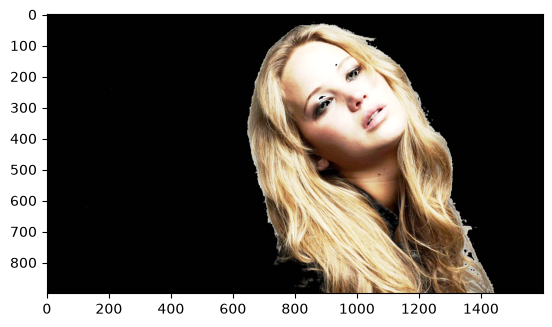

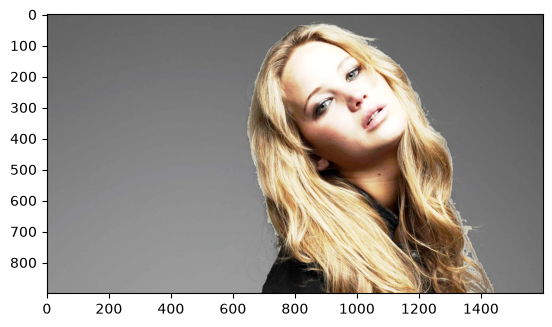

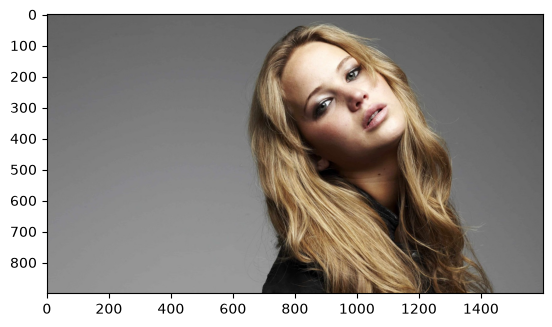

In [38]:
MN = np.sum(fore_hist)
L = 256
lut = np.round((L-1) / MN * cdf).astype(np.uint8)
equalized_foreground = cv.LUT(foreground, lut)
background = cv.bitwise_and(im, im, mask=cv.bitwise_not(mask))
final_result = cv.add(equalized_foreground, background)
plt.imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv.cvtColor(equalized_foreground, cv.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv.cvtColor(final_result, cv.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
plt.show()

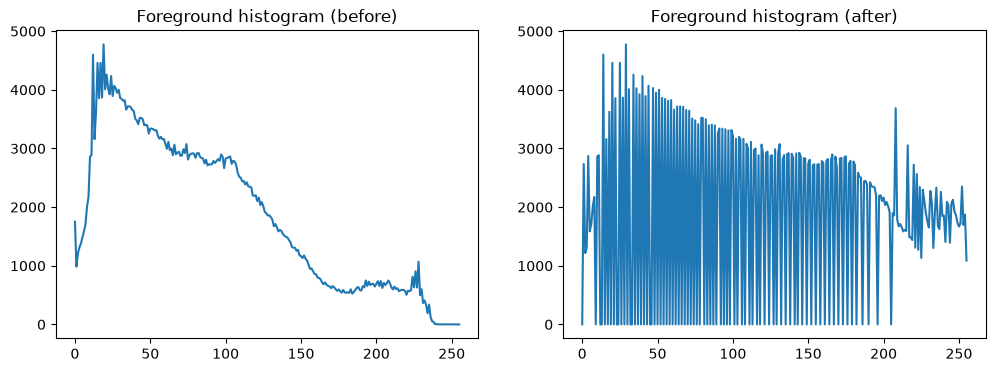

In [39]:
fg_hist_before = cv.calcHist([im], [0], mask, [256], [0,256]).flatten()
fg_hist_after = cv.calcHist([equalized_foreground], [0], mask, [256], [0,256]).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(fg_hist_before)
axes[0].set_title("Foreground histogram (before)")
axes[1].plot(fg_hist_after)
axes[1].set_title("Foreground histogram (after)")
plt.show()

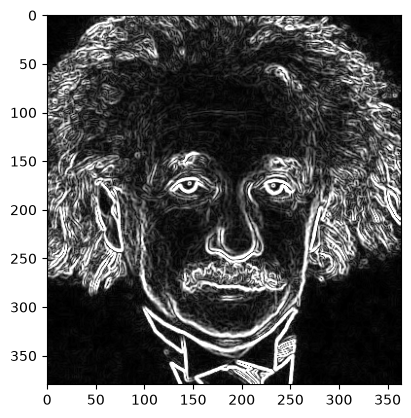

In [41]:
im = cv.imread("images/q7.jpeg", cv.IMREAD_GRAYSCALE)

Gx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32)
Gy = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32)

grad_x = cv.filter2D(im, cv.CV_64F, Gx)
grad_y = cv.filter2D(im, cv.CV_64F, Gy)

magnitude = np.sqrt(grad_x**2 + grad_y**2)
magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)

plt.imshow(magnitude, cmap='gray', vmin=0, vmax=255)

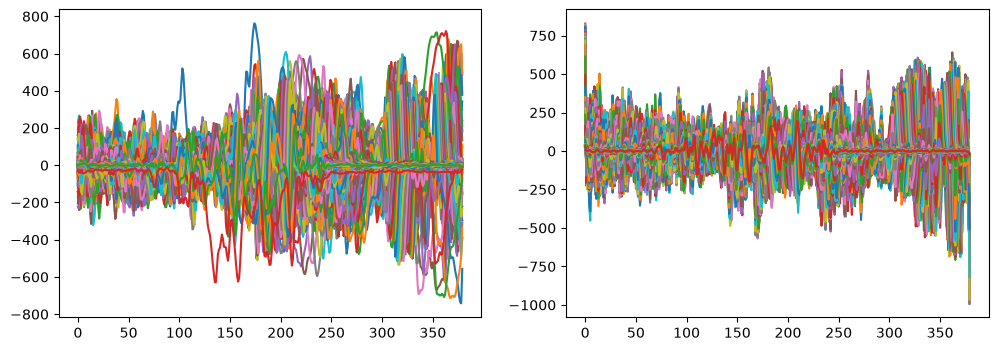

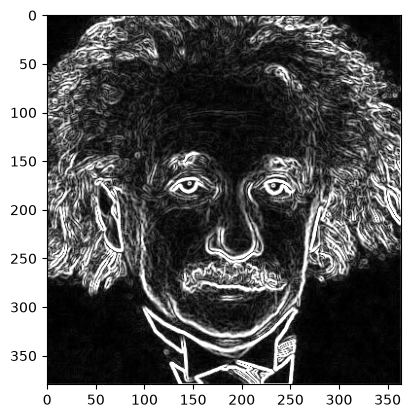

In [48]:
def my_sobel(im, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh//2, kw//2
    padded = np.pad(im, ((pad_h, pad_h),(pad_w, pad_w)), mode='constant')
    out = np.zeros_like(im, dtype=np.float64)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i,j] = np.sum(region * kernel)
    return out

my_grad_x = my_sobel(im, Gx)
my_grad_y = my_sobel(im, Gy)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(my_grad_x)
axes[1].plot(my_grad_y)
plt.show()

my_magnitude = np.sqrt(my_grad_x**2 + my_grad_y**2)
my_magnitude = np.clip(my_magnitude, 0, 255).astype(np.uint8)

plt.imshow(my_magnitude, cmap='gray', vmin=0, vmax=255)

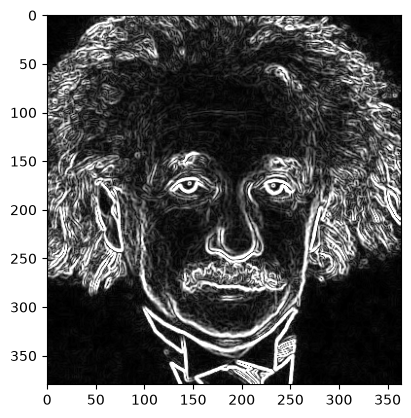

In [51]:
gx_matrix_1 = np.array([[1],[2],[1]], dtype=np.float32)
gx_matrix_2 = np.array([1,0,-1], dtype=np.float32)

gy_matrix_1 = np.array([[1],[0],[-1]], dtype=np.float32)
gy_matrix_2 = np.array([1,2,1], dtype=np.float32)

grad_x_sep = cv.filter2D(cv.filter2D(im, cv.CV_64F, gx_matrix_1), cv.CV_64F, gx_matrix_2)
grad_y_sep = cv.filter2D(cv.filter2D(im, cv.CV_64F, gy_matrix_1), cv.CV_64F, gy_matrix_2)

sep_magnitude = np.sqrt(grad_x_sep**2 + grad_y_sep**2)
sep_magnitude = np.clip(sep_magnitude, 0, 255).astype(np.uint8)

plt.imshow(sep_magnitude, cmap='gray', vmin=0, vmax=255)

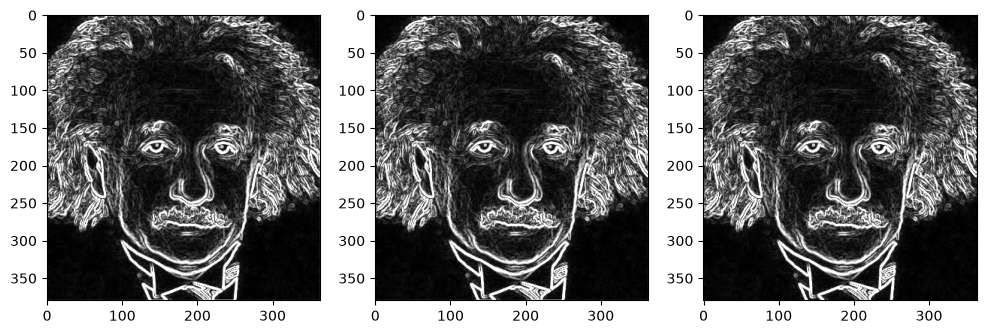

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(magnitude, cmap='gray', vmin=0, vmax=255)
axes[1].imshow(my_magnitude, cmap='gray', vmin=0, vmax=255)
axes[2].imshow(sep_magnitude, cmap='gray', vmin=0, vmax=255)
plt.show()

False
True
Max difference: 255
Mean difference: 0.8459297281665703
SSD: 123.9054005205321
Max difference (cropped): 0
Mean difference (cropped): 0.0


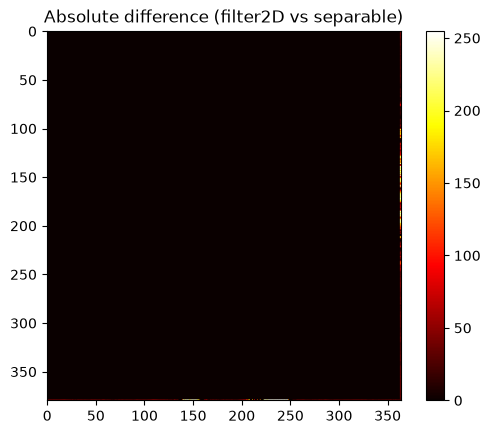

In [55]:
print(np.allclose(magnitude, sep_magnitude))          # filter2D vs separable
print(np.allclose(magnitude, my_magnitude))        # filter2D vs your manual loop

diff = np.abs(magnitude.astype(int) - sep_magnitude.astype(int))
print("Max difference:", diff.max())
print("Mean difference:", diff.mean())

def ssd(a, b):
    a, b = a.astype(np.float64), b.astype(np.float64)
    return np.sum((a - b)**2) / a.size

print("SSD:", ssd(magnitude, sep_magnitude))

crop = 5  # cut off a small border
mag_cropped = magnitude[crop:-crop, crop:-crop]
sep_cropped = sep_magnitude[crop:-crop, crop:-crop]

diff_cropped = np.abs(mag_cropped.astype(int) - sep_cropped.astype(int))
print("Max difference (cropped):", diff_cropped.max())
print("Mean difference (cropped):", diff_cropped.mean())

plt.imshow(diff, cmap='hot')
plt.colorbar()
plt.title("Absolute difference (filter2D vs separable)")
plt.show()

